# ***QMSS 301 — Web Scraping (Reddit Edition)***


WHAT WE'RE COVERING (in order)
1) Warm-up: What is a URL? What is HTTP? What is a GET request?
2) Tiny HTTP demo with requests.get() so students *see* the idea.
3) Reddit scraping the *right* way (PRAW = Reddit's official API).
4) Optional fallback: Reddit’s public JSON endpoint (simple demo).
5) Save results to CSV/JSON and peek with pandas.
6) Light-touch ethics, rate limits, and “don’t get blocked” tips.

 **A quick Introduction**

There are data scattered all around the internet.


The unique address where any of these resources are located is called the **URL (Uniform/Universal Resource Locator)**. The URLs are references to web resources.



**HTTP (HyperText Transfer Protocol)** is the base of data communication on the web. Whenever we interact with the web, we are trying to get data from it, i.e send http request.


HTTP Request (**GET request**) in plane english means getting data from the web.


# **Scrapping Reddit**

APIs(Application Programming Interface) are bunch of codes that allows two softwares to interact or communicate with each other.

For the purpose of collecting data, you can interact with standard websites using their APIs, e.g, reddits API, twitter API, etc.



**Accessing Reddits API**

In order to gain authentication for reddit API, you need to create a reddit developer app account by visiting https://www.reddit.com/prefs/apps. Then chose 'create app'(if you have not done so before', or 'create another app'(if you have created one before). This will open a form like the one below opens.

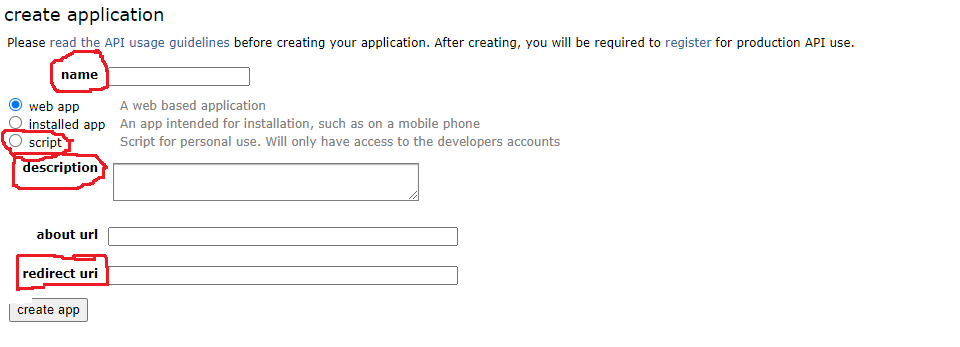

Fill out the form.

**Name** : This is the name you want the app to be called.

Click on **Script**.

**Description**. Give a short description of the app.

**redirect url**: Paste http://localhost:8080 there (don't follow the link, just copy and paste it), as described in PRAW documentation [here](https://praw.readthedocs.io/en/latest/getting_started/authentication.html#script-application).

Click on **create app**.

A new app with details like the one below will come up

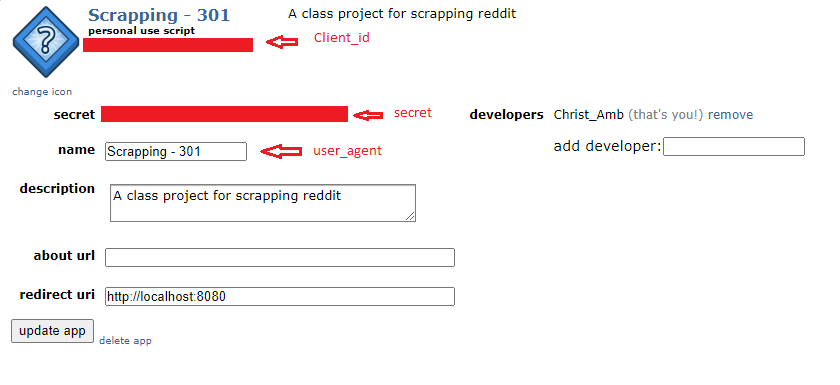

The details of this app will be used to authenticate your access to reddit using praw.

**PRAW** - Python Reddit API Wrapper. It is a python module that is used to collect data from reddit.

In [60]:
#import libraries
!pip install praw 
#This installs the PRAW package, short for Python Reddit API Wrapper.
import requests #lets Python make HTTP requests to websites (like your browser does).
import pandas as pd #used for data analysis and to store results in tables or spreadsheets.
import praw #connects to Reddit’s API to safely collect posts, comments, and user data.

# **Scrapping Subreddit**

In [61]:
# Passing your details
reddit = praw.Reddit(client_id='qPdDcEKwEecqp5V2KQi_yg', # from “personal use script” top line
                     client_secret='sbZdHIXAm4DeVIfLN-pl6d_tBTUPVA', # from “secret” field
                     user_agent='QMSS301-Scraper by u/Intrepid-Adagio-6312') # your Reddit username or project name


In [62]:
# Accessing the subreddit data
sl_sub_data = reddit.subreddit('StudentLoans')    # Now we have our subreddit data in the name 'sl_sub_data'
# https://www.reddit.com/r/StudentLoans/

In [63]:
sl_sub_data

Subreddit(display_name='StudentLoans')

In [64]:
# get 10 hot posts from the StudentLoans subreddit
# The .hot() function retrieves trending content, just like Reddit’s “Hot” tab.
# The limit=10 ensures we don’t overload the API (a key part of ethical scraping).
hot_sl_sub_data = sl_sub_data.hot(limit=10)     # Get the top 10 hot posts from the subreddit
for post in hot_sl_sub_data:                    # Use a for loop to iterate through the post
    print(post.title)       # it will print out the objects id. We can get the title by calling .title
 # We can also get items such as 
# post.title → the post’s title
# post.score → number of upvotes
# post.num_comments → total number of comments
#post.url → direct link

Student Loans -- Politics & Current Events Megathread
How to Identify a Student Loan Scam
Should I keep making payments on Save plan?
Illegally Moved from SAVE Forbearance Back to Standard Repayment
To pay or not to pay interest on SAVE
SAVE plan - in limbo
Is it smart to take the maximum student loan if I don’t need it right now? (Netherlands)
Student Loan Debt
Being told I've reached my aggregate loan limit for grad school even though I haven't attended yet.
Should I pay off my student loans or wait?


In [65]:
# In order to skip the sticky posts, we can add a code line to the previous one
# sticky posts (also called “pinned” posts) are posts that moderators place at the top of a subreddit.
#These posts usually contain rules, announcements, or FAQs — not part of everyday data discussions.
hot_sl_sub_data = sl_sub_data.hot(limit=10)
for post in hot_sl_sub_data:
    if not post.stickied:                 # To skip skicky posts
        print(post.title)

Should I keep making payments on Save plan?
Illegally Moved from SAVE Forbearance Back to Standard Repayment
To pay or not to pay interest on SAVE
SAVE plan - in limbo
Is it smart to take the maximum student loan if I don’t need it right now? (Netherlands)
Student Loan Debt
Being told I've reached my aggregate loan limit for grad school even though I haven't attended yet.
Should I pay off my student loans or wait?


In [66]:
# But we are interested in gathering more information from these posts. One important tool we will need for handling and manipulating the data is pandas
import pandas as pd

more_detail_posts = []                          # Create an empty list, a container that will hold all our post data.
hot_sl_sub_data = sl_sub_data.hot(limit=10)     # Get the top 10 hot posts
for post in hot_sl_sub_data:                    # Initiate a for-loop
  if not post.stickied:                 # To skip skicky posts
    more_detail_posts.append([post.title, 
                              post.score, 
                              post.id, post.subreddit, 
                              post.url, 
                              post.num_comments,
                              post.selftext,
                              post.created]) # append each detail to the empty list
        #post.title, #the post headline.
        #post.score, #total upvotes minus downvotes.
        #post.id, #Reddit’s unique identifier for that post.
        #post.subreddit, #the name of the subreddit (should be StudentLoans here).
        #post.url, #the post’s web address.
        #post.num_comments, #number of comments in the post.
        #post.selftext, #the body or written content of the post.
        #post.created #the date and time the post was created (in Unix timestamp format).
 # Each post becomes one row in our list, ready to turn into a structured dataset.
more_detail_posts = pd.DataFrame(more_detail_posts,columns=['title', 'score', 'id', 'subreddit', 'url', 'num_comments', 'body', 'created']) # Convert to dataframe and name the columns
print(more_detail_posts)

                                               title  score       id  \
0        Should I keep making payments on Save plan?      3  1oto2aj   
1  Illegally Moved from SAVE Forbearance Back to ...      5  1otj2g6   
2              To pay or not to pay interest on SAVE      2  1otqib3   
3                               SAVE plan - in limbo      4  1otk8ri   
4  Is it smart to take the maximum student loan i...      2  1otp697   
5                                  Student Loan Debt     10  1otbv1e   
6  Being told I've reached my aggregate loan limi...      3  1otkoxh   
7         Should I pay off my student loans or wait?      2  1otln17   

      subreddit                                                url  \
0  StudentLoans  https://www.reddit.com/r/StudentLoans/comments...   
1  StudentLoans  https://www.reddit.com/r/StudentLoans/comments...   
2  StudentLoans  https://www.reddit.com/r/StudentLoans/comments...   
3  StudentLoans  https://www.reddit.com/r/StudentLoans/comments...   
4

In [67]:
more_detail_posts.head()

,title,score,id,subreddit,url,num_comments,body,created
0,Should I keep making payments on Save plan?,3,1oto2aj,StudentLoans,https://www.reddit.com/r/StudentLoans/comments...,4,Looking for discussion of my situation. \n\nI ...,1.762804e+09
1,Illegally Moved from SAVE Forbearance Back to ...,5,1otj2g6,StudentLoans,https://www.reddit.com/r/StudentLoans/comments...,10,Nelnet recently moved me out of forbearance ba...,1.762794e+09
2,To pay or not to pay interest on SAVE,2,1otqib3,StudentLoans,https://www.reddit.com/r/StudentLoans/comments...,8,hello I've looked at the sub and while I've se...,1.762810e+09
3,SAVE plan - in limbo,4,1otk8ri,StudentLoans,https://www.reddit.com/r/StudentLoans/comments...,37,"Just to confirm, there is no reason to stay on...",1.762796e+09
4,Is it smart to take the maximum student loan i...,2,1otp697,StudentLoans,https://www.reddit.com/r/StudentLoans/comments...,1,"Hey everyone,\n\nI’m a student in the Netherla...",1.762807e+09


In [68]:
more_detail_posts.shape     # Check the structure of the data

(8, 8)

In [69]:
more_detail_posts.to_csv('our_reddit_data1.csv', index=True, header=True)
#index=True means pandas includes row numbers.
#header=True includes column names at the top of the file.

<span style="color:blue; font-weight:bold; font-size:1.1em;">
### Task: Get the 40 top posts in any subreddit. Only get the title, number of comments, score, and date created.
</span>

# **Scrapping Multiple Subreddits**

In [70]:
# Passing your details
reddit = praw.Reddit(client_id='qPdDcEKwEecqp5V2KQi_yg',
                     client_secret='sbZdHIXAm4DeVIfLN-pl6d_tBTUPVA',
                     user_agent='QMSS301-Scraper by u/Intrepid-Adagio-6312') # Put in your credentials


In [71]:
# Scrapping the data and convert it to dataframe

subredit_list = ["climatechange", "environment", "Environmentalism"]    # make a list of subreddits we want to scrape the data from
posts = [] # Create an empty list

for sub in subredit_list:                   # Initiate a for-loop for each of the subreddit in the subreddit_list
    sub_data = reddit.subreddit(sub)        # Connect to that subreddit using PRAW
    sub_hotpost = sub_data.hot(limit=20)   # Get the top 20 hot posts from each of the subreddit  # https://praw.readthedocs.io/en/v3.6.2/pages/getting_started.html#:~:text=reddit%20allows%20requests%20of%20up,to%20follow%20the%20api%20guidelines.
    for post in sub_hotpost:                # Another for-loop for each post in the sub_hot post
      posts.append([post.title, 
                    post.score, 
                    post.id, 
                    post.subreddit, 
                    post.url, 
                    post.num_comments, 
                    post.selftext, 
                    post.created])     # Append the element of each post to the empty list

posts = pd.DataFrame(posts,columns=['title', 'score', 'id', 'subreddit', 'url', 'num_comments', 'body', 'created'])                 # Convert the data to dataframe
print(posts.shape)
posts.head()

(60, 8)


,title,score,id,subreddit,url,num_comments,body,created
0,The r/climatechange Verified User Flair Program,48,wu9zny,climatechange,https://www.reddit.com/r/climatechange/comment...,23,r/climatechange is a community centered around...,1.661115e+09
1,Study says it's already too late to save the l...,1324,1ot0vh0,climatechange,https://www.earth.com/news/study-already-too-l...,234,It's beginning.,1.762738e+09
2,"As U.S. and E.U. Retreat on Climate, China Tak...",89,1otdvto,climatechange,https://e360.yale.edu/features/china-climate-d...,16,China is not only powering the shift to clean ...,1.762782e+09
3,More Cities Run Dry as Iran’s Water Crisis Dee...,42,1otcx0c,climatechange,https://www.newsweek.com/more-cities-run-dry-i...,3,,1.762779e+09
4,How to explain that climate change isn't being...,9,1otonza,climatechange,https://www.reddit.com/r/climatechange/comment...,78,So I was talking to someone today about climat...,1.762806e+09


In [72]:
# Getting the elements of a specific row
posts.iloc[56]

title           Earth Strike UK: Global General Strike Against...
score                                                          71
id                                                        1orbfzl
subreddit                                        Environmentalism
url             https://classautonomy.info/earth-strike-uk-glo...
num_comments                                                    2
body            Humanity is diving head first in to a climate ...
created                                              1762562405.0
Name: 56, dtype: object

In [73]:
# Accessing a specific cell (row 4, column 'url')
posts.iloc[4]['url']

'https://www.reddit.com/r/climatechange/comments/1otonza/how_to_explain_that_climate_change_isnt_being/'

###***Note:***

The timestamps Reddit gives us (post.created) are in Unix time, which is the number of seconds since January 1, 1970.

To make it human-readable, we’ll use the datetime module to convert it.

In [74]:
# Converting the created date to what we can easily read

from datetime import datetime

posts['date_time'] = pd.to_datetime(posts['created'],  unit='s')   
# pd.to_datetime() converts the numeric timestamp into an actual date and time.
# unit='s' means the timestamp is measured in seconds from 1970.
#This new column (date_time) shows the full date and time of each post.
posts['date'] = posts['date_time'].dt.strftime('%Y-%m-%d') # Now we have created a formatted string, with only the date
#use .strftime('%Y-%m-%d') is a formatting method: %Y → year, %m → month, %d → day


posts.head()

,title,score,id,subreddit,url,num_comments,body,created,date_time,date
0,The r/climatechange Verified User Flair Program,48,wu9zny,climatechange,https://www.reddit.com/r/climatechange/comment...,23,r/climatechange is a community centered around...,1.661115e+09,2022-08-21 20:53:23,2022-08-21
1,Study says it's already too late to save the l...,1324,1ot0vh0,climatechange,https://www.earth.com/news/study-already-too-l...,234,It's beginning.,1.762738e+09,2025-11-10 01:28:57,2025-11-10
2,"As U.S. and E.U. Retreat on Climate, China Tak...",89,1otdvto,climatechange,https://e360.yale.edu/features/china-climate-d...,16,China is not only powering the shift to clean ...,1.762782e+09,2025-11-10 13:33:58,2025-11-10
3,More Cities Run Dry as Iran’s Water Crisis Dee...,42,1otcx0c,climatechange,https://www.newsweek.com/more-cities-run-dry-i...,3,,1.762779e+09,2025-11-10 12:51:48,2025-11-10
4,How to explain that climate change isn't being...,9,1otonza,climatechange,https://www.reddit.com/r/climatechange/comment...,78,So I was talking to someone today about climat...,1.762806e+09,2025-11-10 20:16:11,2025-11-10


In [75]:
posts.shape

(60, 10)

In [76]:
# Remove the duplicate and save data to csv file
posts1 = posts
posts1.drop_duplicates(subset='title', keep='last', inplace=True) 
# in place used to remove duplicates inside posts1 and does not return a new object.
posts1.to_csv('multireddit_data.csv', index=True, header=True)
posts1.shape #view dimension of data to see how many data points remain after cleaning


(58, 10)

# Part 2

# **Word-based search in Reddit**

In [77]:
# Import the necessary libraries
import pandas as pd

# 1. Set the search parameters
word = 'CO2' #The search keyword (here, CO₂).
subreddits = 'climatechange+climate+environment+environmentalism' #Combines multiple communities using +.
sort_by = "hot" #Chooses the post type (‘hot’, ‘new’, or ‘top’).
limit_posts = 100 #Restricts how many posts to retrieve.

# 2. Create a search in the subreddit
top_posts = reddit.subreddit(subreddits).search(word, sort=sort_by, limit=limit_posts)
#reddit.subreddit(...) connects to the subreddits you listed.
#.search() looks for posts containing your keyword.

# 3. Initialize an empty list to store each post's data
all_posts = [] #We create an empty list called all_posts to store results.

# 4. Loop through each post in the search results
for post in top_posts: #Each post object contains attributes like:
    # Create a dictionary for each post's main data
    post_data = {
        "title": post.title,
        "score": post.score,
        "comments": post.num_comments,
        "posted_date": post.created,
        "link": 'https://www.reddit.com' + post.permalink
    }
    # Add the post data to the list
    all_posts.append(post_data)

# Convert the list of dictionaries to a DataFrame
reddit_co2_data = pd.DataFrame(all_posts)

# Print the shape of the DataFrame (rows, columns)
print(reddit_co2_data.shape)

(100, 5)


In [78]:
reddit_co2_data.head()

,title,score,comments,posted_date,link
0,CO2 cools the surface,26,107,1.762542e+09,https://www.reddit.com/r/climatechange/comment...
1,The Evidence is Clear: Bending the CO2 Curve t...,169,4,1.762709e+09,https://www.reddit.com/r/Environmentalism/comm...
2,The Evidence is Clear: Bending the CO2 Curve t...,63,1,1.762709e+09,https://www.reddit.com/r/climate/comments/1osp...
3,Australia's grid now gets half its electricity...,730,69,1.762503e+09,https://www.reddit.com/r/climatechange/comment...
4,Southern Ocean's winter CO₂ outgassing underes...,46,1,1.762375e+09,https://www.reddit.com/r/climate/comments/1ope...


In [81]:
reddit_co2_data.iloc[0]['title']

'CO2 cools the surface'

In [82]:
# Converting the created date to what we can easily read

from datetime import datetime

reddit_co2_data['date_time'] = pd.to_datetime(reddit_co2_data['posted_date'],  unit='s')    # this passes all the time details, including time. # The unit specify what unit our int is is away from the origin
reddit_co2_data['date'] = reddit_co2_data['date_time'].dt.strftime('%Y-%m-%d') # Now we have created a formatted string, with only the date

reddit_co2_data.head()

,title,score,comments,posted_date,link,date_time,date
0,CO2 cools the surface,26,107,1.762542e+09,https://www.reddit.com/r/climatechange/comment...,2025-11-07 19:02:34,2025-11-07
1,The Evidence is Clear: Bending the CO2 Curve t...,169,4,1.762709e+09,https://www.reddit.com/r/Environmentalism/comm...,2025-11-09 17:21:41,2025-11-09
2,The Evidence is Clear: Bending the CO2 Curve t...,63,1,1.762709e+09,https://www.reddit.com/r/climate/comments/1osp...,2025-11-09 17:21:43,2025-11-09
3,Australia's grid now gets half its electricity...,730,69,1.762503e+09,https://www.reddit.com/r/climatechange/comment...,2025-11-07 08:04:04,2025-11-07
4,Southern Ocean's winter CO₂ outgassing underes...,46,1,1.762375e+09,https://www.reddit.com/r/climate/comments/1ope...,2025-11-05 20:32:10,2025-11-05


In [83]:
#save data to csv file, but drop duplicates first
reddit_co2_data1 = reddit_co2_data
reddit_co2_data1.drop_duplicates(subset='title', keep='last', inplace=True) #inplace does not return a new object.
reddit_co2_data1.to_csv('reddit_data1.csv', index=True, header=True)
reddit_co2_data1.shape #view dimension of data to see how many data points remain after cleaning


(93, 7)

# **Scrapping Reddit Comments**

In this section, we will be scrapping the comments from a particular reddit post.

In [84]:
# Passing your details
reddit = praw.Reddit(client_id='qPdDcEKwEecqp5V2KQi_yg', # from “personal use script” top line
                     client_secret='sbZdHIXAm4DeVIfLN-pl6d_tBTUPVA', # from “secret” field
                     user_agent='QMSS301-Scraper by u/Intrepid-Adagio-6312') # your Reddit username or project name


In [86]:
# URL of the post
url = "https://www.reddit.com/r/FluentInFinance/comments/16gegy0/would_you_forgive_student_loan_debt_if_you_were/"

# Creating a submission object
submission = reddit.submission(url=url) #submission function represents a single Reddit post.


In [89]:
# Checking out the content/properties of the post
submission.id       # You can access properties like .title, .id, or .comments.

# But for .comments, what you will have is a comment_forest

'16gegy0'

In [90]:
from praw.models import MoreComments# Importing needed function from praw package

post_comments = []# Create an empty list

for comment in submission.comments:# Initiate a for loop through the comment forest
    if type(comment) == MoreComments:# This helps to handle objects that has “load more comments” and “continue this thread”.
        continue

    post_comments.append(comment.body)# Append the comment body to the empty list

# creating a dataframe
comments_df = pd.DataFrame(post_comments, columns=['comment']) # Convert the 'post_comments' list to dataframe and naming the column.
comments_df


,comment
0,r/FluentInFinance was created to discuss money...
1,[removed]
2,No. quit positing this trash
3,This sub fucking sucks from these comments
4,"No, but I’d crack down on these college racket..."
...,...
120,Saw way too many people failing classes becaus...
121,Fuck yes. And then make all student loans inte...
122,Yes
123,Yes. And I’d make college free. Not out of the...


In [91]:
comments_df.shape

(125, 1)

In [92]:
# Including all the comments within comments (nested comments)
post_comments = []  # Create an empty list


submission.comments.replace_more(limit=None) #loads every comment, nothing left behind.
for comment in submission.comments.list():
 post_comments.append([comment.body, comment.ups, comment.downs, comment.created]) # Append the comment body to the empty list, to have multiple columns for richer analysis.

# creating a dataframe
# Convert the 'post_comments' list to dataframe and naming the column.
comments_df = pd.DataFrame(post_comments, columns=['comment', 'ups', 'downs', 'created'])
comments_df

,comment,ups,downs,created
0,r/FluentInFinance was created to discuss money...,1,0,1.694484e+09
1,[removed],586,0,1.694489e+09
2,No. quit positing this trash,6,0,1.694537e+09
3,This sub fucking sucks from these comments,128,0,1.694497e+09
4,"No, but I’d crack down on these college racket...",19,0,1.694501e+09
...,...,...,...,...
2593,If it was you wouldn’t be crying about how hel...,1,0,1.694655e+09
2594,"Help isn’t coming, we agreed on that.\n\nWe di...",1,0,1.694655e+09
2595,The part where you get to pay for your own loa...,1,0,1.694655e+09
2596,You’re not even replying to the words I’m sayi...,0,0,1.694656e+09


In [93]:
comments_df.shape

(2598, 4)

In [94]:
# Converting the created date to what we can easily read

from datetime import datetime

comments_df['date_time'] = pd.to_datetime(comments_df['created'],  unit='s')    # this passes all the time details, including time. # The unit specify what unit our int is is away from the origin
comments_df['date'] = comments_df['date_time'].dt.strftime('%Y-%m-%d') # Now we have created a formatted string, with only the date

comments_df.head()

,comment,ups,downs,created,date_time,date
0,r/FluentInFinance was created to discuss money...,1,0,1.694484e+09,2023-09-12 01:56:42,2023-09-12
1,[removed],586,0,1.694489e+09,2023-09-12 03:15:30,2023-09-12
2,No. quit positing this trash,6,0,1.694537e+09,2023-09-12 16:47:28,2023-09-12
3,This sub fucking sucks from these comments,128,0,1.694497e+09,2023-09-12 05:41:05,2023-09-12
4,"No, but I’d crack down on these college racket...",19,0,1.694501e+09,2023-09-12 06:43:15,2023-09-12


In [95]:
# Counting characters in the 'comment'
def char_split(text):
    return len(text)
comments_df['character_count'] = comments_df['comment'].apply(char_split)
comments_df

,comment,ups,downs,created,date_time,date,character_count
0,r/FluentInFinance was created to discuss money...,1,0,1.694484e+09,2023-09-12 01:56:42,2023-09-12,359
1,[removed],586,0,1.694489e+09,2023-09-12 03:15:30,2023-09-12,9
2,No. quit positing this trash,6,0,1.694537e+09,2023-09-12 16:47:28,2023-09-12,28
3,This sub fucking sucks from these comments,128,0,1.694497e+09,2023-09-12 05:41:05,2023-09-12,42
4,"No, but I’d crack down on these college racket...",19,0,1.694501e+09,2023-09-12 06:43:15,2023-09-12,139
...,...,...,...,...,...,...,...
2593,If it was you wouldn’t be crying about how hel...,1,0,1.694655e+09,2023-09-14 01:23:35,2023-09-14,74
2594,"Help isn’t coming, we agreed on that.\n\nWe di...",1,0,1.694655e+09,2023-09-14 01:31:41,2023-09-14,258
2595,The part where you get to pay for your own loa...,1,0,1.694655e+09,2023-09-14 01:34:54,2023-09-14,193
2596,You’re not even replying to the words I’m sayi...,0,0,1.694656e+09,2023-09-14 01:41:55,2023-09-14,538


In [58]:
# Counting words in the 'comment'
def word_split(text):
    words = text.split()
    return len(words)
comments_df['word_count'] = comments_df['comment'].apply(word_split)
comments_df

,comment,ups,downs,created,date_time,date,character_count,word_count
0,r/FluentInFinance was created to discuss money...,1,0,1.694484e+09,2023-09-12 01:56:42,2023-09-12,359,44
1,[removed],585,0,1.694489e+09,2023-09-12 03:15:30,2023-09-12,9,1
2,No. quit positing this trash,5,0,1.694537e+09,2023-09-12 16:47:28,2023-09-12,28,5
3,This sub fucking sucks from these comments,126,0,1.694497e+09,2023-09-12 05:41:05,2023-09-12,42,7
4,"No, but I’d crack down on these college racket...",19,0,1.694501e+09,2023-09-12 06:43:15,2023-09-12,139,25
...,...,...,...,...,...,...,...,...
2593,If it was you wouldn’t be crying about how hel...,1,0,1.694655e+09,2023-09-14 01:23:35,2023-09-14,74,14
2594,"Help isn’t coming, we agreed on that.\n\nWe di...",1,0,1.694655e+09,2023-09-14 01:31:41,2023-09-14,258,45
2595,The part where you get to pay for your own loa...,1,0,1.694655e+09,2023-09-14 01:34:54,2023-09-14,193,37
2596,You’re not even replying to the words I’m sayi...,0,0,1.694656e+09,2023-09-14 01:41:55,2023-09-14,538,93


In [59]:
# Remove the duplicate and save data to csv file
comments_df1 = comments_df
comments_df1.drop_duplicates(subset='comment', keep='last', inplace=True)
comments_df1.to_csv('sl_comments.csv', index=True, header=True)
comments_df1.shape #view dimension of data to see how many data points remain after cleaning


(2489, 8)